# Book Recommendation System

This project builds a book recommendation system using collaborative filtering. The goal is to recommend similar books based on user rating patterns.


## Objective

The objective of this project is to analyze book rating data, reduce noise through filtering, and build a recommendation system that suggests similar books to users based on past rating behavior.


## Importing Libraries

The required libraries were imported for data manipulation, visualization, sparse matrix conversion, and model building.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd


#loading the first dataset (books.csv)

books = pd.read_csv("Books.csv", encoding="latin-1")

books = books[['ISBN', 'Book-Title', 'Book-Author', 'Year-Of-Publication', 'Publisher', 'Image-URL-L']]

books = books.rename(columns={
    'ISBN': 'isbn',
    'Book-Title': 'title',
    'Book-Author': 'author',
    'Year-Of-Publication': 'year',
    'Publisher': 'publisher',
    'Image-URL-L': 'image_url'
})

books.head()

C:\Users\furez\AppData\Local\Temp\ipykernel_23188\567662935.py:9: DtypeWarning: Columns (0: Year-Of-Publication) have mixed types. Specify dtype option on import or set low_memory=False.
  books = pd.read_csv("Books.csv", encoding="latin-1")


,isbn,title,author,year,publisher,image_url
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...
3,0374157065,Flu: The Story of the Great Influenza Pandemic...,Gina Bari Kolata,1999,Farrar Straus Giroux,http://images.amazon.com/images/P/0374157065.0...
4,0393045218,The Mummies of Urumchi,E. J. W. Barber,1999,W. W. Norton &amp; Company,http://images.amazon.com/images/P/0393045218.0...


## Loading the Datasets

The books, users, and ratings datasets were loaded into the notebook for analysis and model development.

In [2]:
# loading the second dataset (users.csv)

users = pd.read_csv("Users.csv", encoding="latin-1")


users.rename(columns={'User-ID': 'user_id',
                       'Location': 'location', 
                       'Age': 'age'}, inplace=True)

users.head()

,user_id,location,age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN
3,4,"porto, v.n.gaia, portugal",17.0
4,5,"farnborough, hants, united kingdom",NaN


In [3]:
# now lets load the third dataset (ratings .csv)

ratings = pd.read_csv("Ratings.csv", encoding="latin-1")


ratings.rename(columns={'User-ID': 'user_id',
                       'ISBN': 'isbn',
                       'Book-Rating': 'rating'}, inplace=True)

ratings.head()


,user_id,isbn,rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0
3,276729,052165615X,3
4,276729,0521795028,6


## Initial Data Inspection

The datasets were inspected to understand their structure, column names, and overall size. This step helps identify the main variables needed for analysis and recommendation.



## Exploratory Data Analysis

Exploratory Data Analysis was performed to understand the rating data, user activity, and book popularity. This helps reveal patterns in the dataset before building the recommendation model.

- Who is the most active user/ who is reading highest number of books?

In [4]:
ratings['user_id'].value_counts()

user_id
11676     13602
198711     7550
153662     6109
98391      5891
35859      5850
          ...  
276697        1
276706        1
276709        1
276721        1
276723        1
Name: count, Length: 105283, dtype: int64

### Most Active Users

User activity was examined to identify users who contributed a large number of ratings. These active users provide stronger signals for collaborative filtering.


### Filtering popular books

To reduce sparsity and noise in the dataset, only users with at least 200 ratings were retained.


In [5]:
X = ratings['user_id'].value_counts() > 200

X

user_id
11676      True
198711     True
153662     True
98391      True
35859      True
          ...  
276697    False
276706    False
276709    False
276721    False
276723    False
Name: count, Length: 105283, dtype: bool

In [6]:
X[X].shape

(899,)

In [7]:
y = X[X].index
y

Index([ 11676, 198711, 153662,  98391,  35859, 212898, 278418,  76352, 110973,
       235105,
       ...
       260183,   9856,  28634,  44296,  59727,  73681, 155916, 188951, 268622,
       274808],
      dtype='int64', name='user_id', length=899)

### Filtering Active Users

Only users with a high number of ratings were retained. This was done to focus on users with enough interaction history to contribute meaningful patterns.

In [8]:
ratings = ratings[ratings['user_id'].isin(y)]
ratings.head()

,user_id,isbn,rating
1456,277427,002542730X,10
1457,277427,0026217457,0
1458,277427,003008685X,8
1459,277427,0030615321,0
1460,277427,0060002050,0


## Merging Ratings and Books 

In [9]:
ratings_with_books = ratings.merge(books, on = 'isbn')
ratings_with_books.head()

,user_id,isbn,rating,title,author,year,publisher,image_url
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...
2,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,http://images.amazon.com/images/P/0060002050.0...


## Number of Ratings per Book

In [10]:
number_of_ratings = ratings_with_books.groupby('title').count()['rating'].reset_index()
number_of_ratings.rename(columns={'rating': 'number_of_ratings'}, inplace=True)
number_of_ratings.head()

,title,number_of_ratings
0,A Light in the Storm: The Civil War Diary of ...,2
1,Always Have Popsicles,1
2,Apple Magic (The Collector's series),1
3,Beyond IBM: Leadership Marketing and Finance ...,1
4,Clifford Visita El Hospital (Clifford El Gran...,1


### Final Ratings Dataset
This dataframe contains the filtered book-rating records along with the number of ratings per title.

In [ ]:
final_ratings = ratings_with_books.merge(number_of_ratings, on = 'title')
final_ratings.drop_duplicates(subset=['user_id', 'title'], inplace=True)
final_ratings.head()


,user_id,isbn,rating,title,author,year,publisher,image_url,number_of_ratings
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,82
1,277427,0026217457,0,Vegetarian Times Complete Cookbook,Lucy Moll,1995,John Wiley &amp; Sons,http://images.amazon.com/images/P/0026217457.0...,7
2,277427,003008685X,8,Pioneers,James Fenimore Cooper,1974,Thomson Learning,http://images.amazon.com/images/P/003008685X.0...,1
3,277427,0030615321,0,"Ask for May, Settle for June (A Doonesbury book)",G. B. Trudeau,1982,Henry Holt &amp; Co,http://images.amazon.com/images/P/0030615321.0...,1
4,277427,0060002050,0,On a Wicked Dawn (Cynster Novels),Stephanie Laurens,2002,Avon Books,http://images.amazon.com/images/P/0060002050.0...,13


### Filtering Popular Books

Only books with at least 50 ratings were kept in the final dataset. This helps avoid weak recommendations based on books with too little rating data.


In [12]:
final_ratings_50 = final_ratings[final_ratings['number_of_ratings']>=50]
final_ratings_50.head()

,user_id,isbn,rating,title,author,year,publisher,image_url,number_of_ratings
0,277427,002542730X,10,Politically Correct Bedtime Stories: Modern Ta...,James Finn Garner,1994,John Wiley &amp; Sons Inc,http://images.amazon.com/images/P/002542730X.0...,82
13,277427,0060930535,0,The Poisonwood Bible: A Novel,Barbara Kingsolver,1999,Perennial,http://images.amazon.com/images/P/0060930535.0...,133
15,277427,0060934417,0,Bel Canto: A Novel,Ann Patchett,2002,Perennial,http://images.amazon.com/images/P/0060934417.0...,108
18,277427,0061009059,9,One for the Money (Stephanie Plum Novels (Pape...,Janet Evanovich,1995,HarperTorch,http://images.amazon.com/images/P/0061009059.0...,108
24,277427,006440188X,0,The Secret Garden,Frances Hodgson Burnett,1998,HarperTrophy,http://images.amazon.com/images/P/006440188X.0...,79


### Insights
- I filtered the dataset by keeping only highly active users and books with a sufficient number of ratings, in order to reduce sparsity and improve the reliability of the recommendation system.

### Average Rating and Number of Ratings

A summary table was created for each book using its average rating and number of ratings. This helps distinguish between books that are highly rated and books that are simply popular.

In [13]:
average_rating = final_ratings.groupby('title')['rating'].agg(['mean', 'count']).reset_index()
average_rating.head()

,title,mean,count
0,A Light in the Storm: The Civil War Diary of ...,4.5,2
1,Always Have Popsicles,0.0,1
2,Apple Magic (The Collector's series),0.0,1
3,Beyond IBM: Leadership Marketing and Finance ...,0.0,1
4,Clifford Visita El Hospital (Clifford El Gran...,0.0,1



### Rating Distribution

The distribution of rating values was analyzed to observe how users rated books overall. This helps identify whether the ratings are balanced or skewed toward certain values.

In [ ]:
final_ratings_50['rating'].value_counts().sort_index()




rating
0     44889
1        62
2        63
3       106
4       200
5      1371
6       924
7      2251
8      3639
9      2987
10     3358
Name: count, dtype: int64

## Final Cleaned Dataset

After filtering and removing duplicates, a final cleaned dataset was prepared. This dataset was used for creating the pivot table and training the recommendation model.

<Axes: xlabel='rating'>

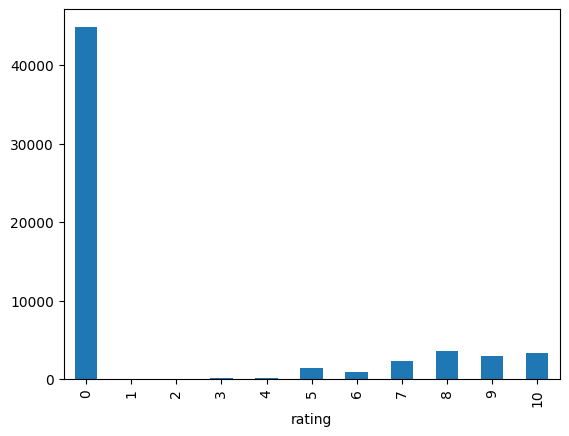

In [ ]:



final_ratings_50['rating'].value_counts().sort_index().plot(kind='bar')


### Insights 

- The rating distribution is highly skewed because rating 0 appears far more often than explicit ratings. Among explicit ratings, users tend to give higher scores, with most ratings concentrated between 7 and 10.

### Creating the pivot table

A pivot table is created with book titles as rows, user IDs as columns, and ratings as values. This structure converts the dataset into a book-user matrix that can be used for similarity-based recommendation.

In [ ]:

pt = final_ratings_50.pivot_table(index='title', columns='user_id', values='rating').fillna(0)
pt.head()


user_id,254,2276,2766,2977,3363,3757,4017,4385,6242,6251,...,274004,274061,274301,274308,274808,275970,277427,277478,277639,278418
title,,,,,,,,,,,,,,,,,,,,,
1984,9.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1st to Die: A Novel,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2nd Chance,0.0,10.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4 Blondes,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
84 Charing Cross Road,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,10.0,0.0,0.0,0.0,0.0


In [17]:
pt.shape

(742, 888)

## Sparse Matrix Conversion

The pivot table was converted into a sparse matrix to handle the large number of zero values efficiently. This reduces memory usage and is suitable for recommendation models.

In [18]:
from scipy.sparse import csr_matrix
pt_sparse = csr_matrix(pt.values)
pt_sparse

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 14961 stored elements and shape (742, 888)>

## Model Building

A K-Nearest Neighbors model was built using cosine distance to find books with similar user rating patterns. Cosine similarity is useful because it compares rating behavior rather than just rating counts.

In [31]:
from sklearn.neighbors import NearestNeighbors 
model = NearestNeighbors(metric='cosine')  
model.fit(pt_sparse)  


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"radius radius: float, default=1.0Range of parameter space to use by default for :meth:`radius_neighbors`queries.",1.0
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'cosine'
,"p p: float (positive), default=2Parameter for the Minkowski metric fromsklearn.metrics.pairwise.pairwise_distances. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None


In [ ]:

pt.iloc[237]


user_id
254       9.0
2276      0.0
2766      0.0
2977      0.0
3363      0.0
         ... 
275970    9.0
277427    0.0
277478    0.0
277639    0.0
278418    0.0
Name: Harry Potter and the Chamber of Secrets (Book 2), Length: 888, dtype: float64

## Generating Recommendations

In [21]:
distance , suggestions = model.kneighbors(pt.iloc[238, :].values.reshape(1, -1), n_neighbors=6)
suggestions

array([[238, 240, 237, 239, 241, 242]])

In [22]:
for i in suggestions[0][1:]:
    print(pt.index[i])

Harry Potter and the Prisoner of Azkaban (Book 3)
Harry Potter and the Chamber of Secrets (Book 2)
Harry Potter and the Order of the Phoenix (Book 5)
Harry Potter and the Sorcerer's Stone (Book 1)
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))


### Testing the model

- When testing the model on 'Harry Potter and the Chamber of Secrets (Book 2)', the recommended books were mostly other Harry Potter titles. This suggests the model is effectively capturing similarity in user rating patterns, especially for books belonging to the same series.

- The model is tested on different book titles to evaluate whether the recommendations were meaningful. Popular and series-based books produced stronger recommendations, while overlap in some results suggested common nearest neighbors in the dataset.


In [ ]:

distance , suggestions_2 = model.kneighbors(pt.iloc[184, :].values.reshape(1, -1), n_neighbors=6)
suggestions_2

array([[184, 536, 597, 187, 204, 442]])

In [24]:
for i in suggestions_2[0][1:]:
    print(pt.index[i])

The Cradle Will Fall
The Long Road Home
Eyes of a Child
Fine Things
Secrets


In [ ]:
distance , suggestions_3 = model.kneighbors(pt.iloc[536, :].values.reshape(1, -1), n_neighbors=6)
suggestions_3


array([[536, 184, 187,  70, 442, 597]])

In [26]:
for i in (suggestions_3[0][1:]):
    print(pt.index[i])

Exclusive
Eyes of a Child
Before I Say Good-Bye
Secrets
The Long Road Home


### Test Observation

When tested on a Harry Potter title, the model recommended other Harry Potter books, which shows that it captured strong similarity patterns within the same series. This suggests that the model is learning meaningful relationships from user ratings.

In [ ]:
pt.index[pt.index.str.contains('Harry Potter', case=False)]

Index(['Harry Potter and the Chamber of Secrets (Book 2)',
       'Harry Potter and the Goblet of Fire (Book 4)',
       'Harry Potter and the Order of the Phoenix (Book 5)',
       'Harry Potter and the Prisoner of Azkaban (Book 3)',
       'Harry Potter and the Sorcerer's Stone (Book 1)',
       'Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))'],
      dtype='str', name='title')

In [28]:
book_title = pt.index
book_title

Index(['1984', '1st to Die: A Novel', '2nd Chance', '4 Blondes',
       '84 Charing Cross Road', 'A Bend in the Road', 'A Case of Need',
       'A Child Called \It\": One Child's Courage to Survive"',
       'A Civil Action', 'A Cry In The Night',
       ...
       'Winter Solstice', 'Wish You Well', 'Without Remorse',
       'Wizard and Glass (The Dark Tower, Book 4)', 'Wuthering Heights',
       'Year of Wonders', 'You Belong To Me',
       'Zen and the Art of Motorcycle Maintenance: An Inquiry into Values',
       'Zoya', '\O\" Is for Outlaw"'],
      dtype='str', name='title', length=742)

## Recommendation Function

A recommendation function was created to return similar books for any given title. This makes the model reusable and allows testing on different books easily.

In [29]:

def recommend_books(book_title):
    book_index = np.where(pt.index == book_title)[0][0]
    distance , suggestions = model.kneighbors(pt.iloc[book_index, :].values.reshape(1, -1), n_neighbors=6)

    recommended_books = []
    for i in (suggestions[0][1:]):
        recommended_books.append(pt.index[i])
    return recommended_books

In [30]:
recommend_books("The Secret Garden")

['That Camden Summer',
 'A Walk to Remember',
 'The Mulberry Tree',
 'The Bad Beginning (A Series of Unfortunate Events, Book 1)',
 'Circle of Friends']

### Additional Observation

Some recommendations overlapped across different input books. This may be due to shared reader preferences, dataset sparsity, or highly popular books acting as common nearest neighbors.

## Final Insights

- The recommendation system was able to identify similar books based on user rating behavior.
- Results were more meaningful for books with richer rating history.
- This project shows how collaborative filtering can be used to build a basic book recommendation system.

## Conclusion

This project demonstrates how collaborative filtering can be used to build a basic book recommendation system. By cleaning the data, reducing sparsity, and applying K-Nearest Neighbors with cosine distance, the model was able to recommend books with similar user rating patterns.